# Multi-harmonic Viterbi search for EMRIs

This notebook prototypes a **semi-coherent, multi-harmonic Viterbi search** for the gravitational-wave signal of an Extreme Mass-Ratio Inspiral (EMRI) in simulated LISA data.

The pipeline is:

1. **Generate a synthetic EMRI signal** with the FastEMRIWaveforms (`few`) package, add coloured LISA noise, and chop the time series into **Short Fourier Transforms (SFTs)** — a time–frequency spectrogram.
2. **Score each candidate track** with a Fresnel-kernel, amplitude-agnostic emission: within each SFT the signal is a slowly-varying chirp, so the matched-filter contribution of every harmonic is a Fresnel-weighted coherent sum over bins, normalised to a per-harmonic SNR².
3. **Track the inspiral** through a Viterbi dynamic program whose latent state is the 4-tuple $(f_\phi, \dot f_\phi, f_r, \dot f_r)$, summing power over the harmonic comb $f_{mn}=m f_\phi + n f_r$ and enforcing the inspiral physics (continuity + chirp-up) through a banded transition.

The signal is a slowly evolving multi-voice chirp. Within one SFT each harmonic's instantaneous frequency sweeps by a small amount (captured by the Fresnel kernel); across segments the fundamentals trace out smooth, monotonically rising tracks. The Viterbi step finds the track that maximises the accumulated statistic subject to the physical constraints of an inspiral, and the recovered $(f_\phi, f_r)(t)$ — with chirp rates — serve as a trigger to localise the source and seed a coherent follow-up.

In [ ]:
# imports 
import numpy as np
import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", True)
import equinox as eqx

rng = np.random.default_rng(0)

: 

## 1. Source parameters

An EMRI is a small compact object of mass $m_2$ spiralling into a massive (Kerr) black hole of mass $m_1$, with mass ratio $\varepsilon = m_2/m_1 \sim 10^{-5}$. The system is described by:

- **Intrinsic parameters**: primary mass $m_1$, secondary mass $m_2$, dimensionless Kerr spin $a$, and the initial geodesic orbital elements — semi-latus rectum $p_0$, eccentricity $e_0$, and inclination $x_0 = \cos\iota$.
- **Initial phases** $(\Phi_{\phi 0}, \Phi_{\theta 0}, \Phi_{r 0})$ of the azimuthal, polar and radial motions.
- **Extrinsic parameters**: luminosity distance `dist`, sky location $(\theta_S,\phi_S)$ = `(qS, phiS)`, and spin orientation $(\theta_K,\phi_K)$ = `(qK, phiK)`.
- **Observation settings**: total time `T` (years) and sampling cadence `dt` (seconds).

Because the mass ratio is tiny, the orbit evolves *adiabatically*: over any short interval it is nearly a fixed geodesic with three fundamental frequencies $(f_\phi, f_\theta, f_r)$, and these drift slowly as the orbit shrinks. This separation of timescales is exactly what the SFT + Viterbi approach exploits.

In [7]:
# Set EMRI params and create synthetic data
emri_params = {
    'm1': 1e6, 
    'm2': 10.0, 
    'a': 0.99, 
    'p0': 7.0, 
    'e0': 0.7, 
    'x0': 1.0,
    'dist': 1.0, 
    'qS': 0.2, 
    'phiS': 0.2, 
    'qK': 0.8, 
    'phiK': 0.8,
    'Phi_phi0': 0.0, 
    'Phi_theta0': 0.0, 
    'Phi_r0': 0.0, 
    'T': 2.0, 
    'dt': 5.0
}

In [8]:
#  Load FEW trajectory and comp-ute T_plunge and e_f
from few. trajectory.inspiral import EMRIInspiral
traj = EMRIInspiral(func='KerrEccEqFlux')

## 2. The inspiral trajectory

`EMRIInspiral` integrates the adiabatic equations of motion for the orbital elements. Schematically, the radiation-reaction fluxes drive

$$\frac{dp}{dt} = \dot p(p,e,a),\qquad \frac{de}{dt} = \dot e(p,e,a),\qquad \frac{dx_I}{dt}=\dot x_I(p,e,a),$$

where the right-hand sides come from the `KerrEccEqFlux` model (interpolated Teukolsky-based energy and angular-momentum fluxes for eccentric equatorial Kerr orbits). Alongside the orbital elements the solver returns the **orbital phases** obtained by integrating the fundamental frequencies,

$$\Phi_\phi(t)=\int_0^t \Omega_\phi\,dt',\quad \Phi_\theta(t)=\int_0^t \Omega_\theta\,dt',\quad \Phi_r(t)=\int_0^t \Omega_r\,dt'.$$

The integration stops at the **separatrix**, the boundary between stable orbits and plunge. The call below returns the time samples `t` together with $p(t), e(t), x_I(t)$ and the three phases.

In [9]:
traj_pars= traj_pars = [
    emri_params['m1'], 
    emri_params['m2'], 
    emri_params['a'], 
    emri_params['p0'], 
    emri_params['e0'], 
    emri_params['x0']
    ]
t, p, e, xI, Phi_phi, Phi_theta, Phi_r = traj(*traj_pars, T=emri_params['T'])

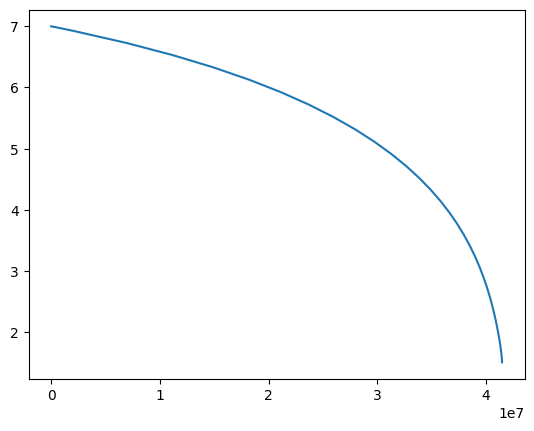

In [10]:
import matplotlib.pyplot as plt
plt.plot(t, p)

In [11]:
print(f'Final p: {p[-1]}, Final e: {e[-1]}')

Final p: 1.504808821388181, Final e: 0.0817159597127215


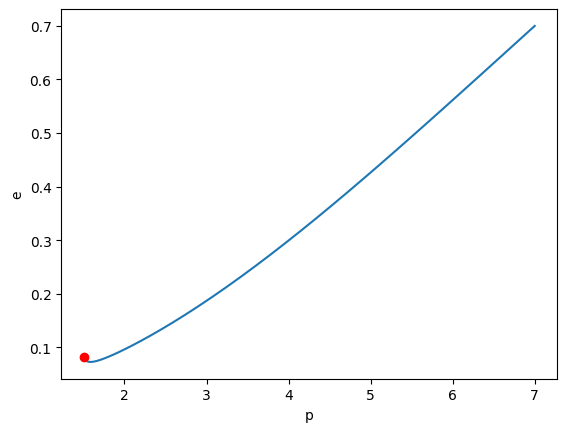

In [12]:
# phase space plot
plt.plot(p, e)
plt.xlabel('p')
plt.ylabel('e')

# indicate plunge with a red dot
plt.plot(p[-1], e[-1], 'ro')

The $(p, e)$ plot is the **phase portrait** of the inspiral. The orbit drifts to smaller $p$ as energy and angular momentum are radiated; the eccentricity first grows slightly and then decreases (circularisation) as the body approaches the separatrix. The red dot marks the final point $(p_{\mathrm{sep}}, e_f)$ where the trajectory terminates — the start of the plunge. The plunge time $T_{\mathrm{plunge}} = t_{-1}$ and the final eccentricity $e_f$ are the key quantities that the search later uses to re-parametrise the source.

In [13]:
# Generate synthetic data and transform into SFTs
# Use Lorenzo's function for this
from few.utils.constants import YRSID_SI
from emrisearch.search_utils import generate_emri_signal_and_sfts
from emrisearch.emri_utils import get_f_fdot_fddot_back
from emrisearch.jax_utils import det_stat as jax_det_stat, psd
from emrisearch.track_optimizer import (
    TrackOptimizer, TrackOptimizerJAX, estimate_plunge_time,
    get_default_mode_candidates, DEFAULT_BOUNDS,
)

print("JAX devices:", jax.devices())

JAX devices: [CpuDevice(id=0)]


In [14]:
t

array([0.00000000e+00, 1.96028491e+04, 6.58585870e+04, 1.87005953e+05,
       5.23915125e+05, 2.02599571e+06, 6.95413803e+06, 1.11650980e+07,
       1.49003548e+07, 1.82041475e+07, 2.11277883e+07, 2.37043810e+07,
       2.59721631e+07, 2.79785178e+07, 2.97389685e+07, 3.12874086e+07,
       3.26471390e+07, 3.38405669e+07, 3.48871857e+07, 3.58036932e+07,
       3.66097362e+07, 3.73177735e+07, 3.79391435e+07, 3.84851852e+07,
       3.89654326e+07, 3.93837476e+07, 3.97444304e+07, 4.00508595e+07,
       4.03091683e+07, 4.05286313e+07, 4.07192063e+07, 4.08598110e+07,
       4.09798398e+07, 4.10724009e+07, 4.11472661e+07, 4.12082499e+07,
       4.12584162e+07, 4.12991958e+07, 4.13326468e+07, 4.13600843e+07,
       4.13818572e+07, 4.13986299e+07, 4.14128541e+07, 4.14238036e+07,
       4.14324057e+07, 4.14394727e+07, 4.14450644e+07, 4.14494398e+07,
       4.14528136e+07, 4.14554138e+07, 4.14574026e+07, 4.14589214e+07,
       4.14600898e+07, 4.14609777e+07, 4.14616495e+07, 4.14621554e+07,
      

In [15]:
t[-1]/YRSID_SI

np.float64(1.3138773059095477)

## 3. Re-parametrising the source for the search

Rather than searching over the initial elements $(p_0, e_0, \Phi_{r0}, \dots)$, the search uses a parametrisation anchored at the **end** of the inspiral:

$$\boldsymbol{\theta} = (m_1,\; m_2,\; a,\; T_{\mathrm{plunge}},\; e_f,\; x_0).$$

Here $T_{\mathrm{plunge}} = t_{-1}/\text{YRSID\_SI}$ is the time-to-plunge in years and $e_f = e(t_{-1})$ is the eccentricity at the separatrix. Given $(m_1, m_2, a, e_f, x_0)$ and a plunge time, the trajectory can be integrated *backwards* to recover the frequency evolution over the observation window — which is exactly what `get_f_fdot_fddot_back` does. This anchoring is numerically convenient because the plunge endpoint is sharply defined, whereas the initial $p_0$ is degenerate with the observation start time.

In [16]:
emri_params['T_plunge'] = t[-1]/YRSID_SI
emri_params['e_f'] = e[-1]
emri_params['p_sep'] = p[-1]

In [17]:
true_values = np.array([emri_params['m1'], 
                        emri_params['m2'], 
                        emri_params['a'], 
                        emri_params['T_plunge'], 
                        emri_params['e_f'], 
                        emri_params['x0']])

T_data  = 0.2     # years (short, for a fast demo)
T_sft   = 5e4     # seconds (~14 h)
deltaT  = 5.0     # seconds
snr_ref = 30.0

In [1]:
from emrisearch.da_utils import psd, sft_inner_product, compute_sfts, generate_noise, get_snr

Using TDI PSD
Using TDI PSD


In [3]:
from emrisearch.emri_utils import create_signal, get_f_fdot_fddot_back   

In [ ]:
# we load one of the Mojito datasets and generate noise for it from the PSD, then sum signal + noise and compute the SFTs
# fastlisaresponse + FEW is broken by some recent updates,

## 4. Synthetic data: signal + noise as SFTs

**Data model.** The detector time series is signal plus stationary Gaussian noise,
$$d(t) = h(t;\boldsymbol\theta) + n(t),\qquad \langle \tilde n(f)\,\tilde n^*(f')\rangle = \tfrac12 S_n(f)\,\delta(f-f'),$$
where $S_n(f)$ is the one-sided LISA power spectral density (PSD) and $\tilde{}$ denotes the Fourier transform.

**SFTs (Short Fourier Transforms).** The series is split into $N_{\mathrm{seg}}$ contiguous segments of length $T_{\mathrm{sft}}$ (here `T_sft` $\approx 14$ h, $=$ `samples_per_sft` $\times$ `deltaT`). A Tukey window $w$ tapers each segment to suppress spectral leakage, and the FFT of segment $\alpha$ gives
$$\tilde d_\alpha(f_k),\qquad f_k = k\,\Delta f,\quad \Delta f = 1/T_{\mathrm{sft}}.$$
The result is a complex spectrogram of shape $(N_{\mathrm{freq}}, N_{\mathrm{seg}})$. The segment length sets the trade-off: it must be long enough for good frequency resolution $\Delta f$, but short enough that each harmonic's frequency drifts by less than one bin within a segment (so the line stays sharp).

**SNR and matched filtering.** The noise-weighted inner product between two SFT sets is
$$\langle a\mid b\rangle = 4\,\mathrm{Re}\sum_{\alpha}\sum_k \frac{\tilde a_\alpha(f_k)\,\tilde b^*_\alpha(f_k)}{S_n(f_k)}\,\Delta f,$$
implemented by `sft_inner_product`. The optimal matched-filter SNR is $\rho = \sqrt{\langle h\mid h\rangle}$, and the function rescales the injected signal so that $\rho = $ `snr_ref`. The diagnostics returned are the signal–data, signal–signal and signal–noise overlaps
$$m_{hd}=\langle h\mid d\rangle,\qquad m_{hh}=\langle h\mid h\rangle,\qquad m_{hn}=\langle h\mid n\rangle,$$
so that $m_{hd}\approx m_{hh} + m_{hn}$ with $\mathbb{E}[m_{hn}]=0$ — a sanity check that the injected track carries the expected power.

In [ ]:
from scipy.signal.windows import tukey
def generate_emri_signal_and_sfts(true_values, T_data, T_sft, deltaT, snr_ref, T_snr):
    """
    Generate EMRI signal, compute SFTs, and prepare data for analysis.
    
    Parameters:
    -----------
    true_values : np.ndarray
        EMRI parameters [m1, m2, a, Tpl, ef, x0]
    T_data : float
        Total data duration in years
    T_sft : float
        SFT duration in seconds
    deltaT : float
        Time step in seconds
    snr_ref : float
        SNR of the signal with duration T_snr
    T_snr : float
        Duration of the signal in years it must be always bigger or equal to T_data

    Returns:
    --------
    dict : Dictionary containing:
        - 't': trimmed time array
        - 'signal_sfts': SFTs of the signal
        - 'noise_sfts': SFTs of noise realization
        - 'new_noise_sfts': SFTs of second noise realization
        - 'data_sfts': SFTs of signal + noise
        - 't_alpha': time samples for SFTs
        - 'samples_per_sft': number of samples per SFT
        - 'wind': window function
        - 'snr_final': final SNR of scaled signal
        - 'true_phi_f_fdot_fddot': frequency evolution parameters
    """
    # Generate EMRI signal
    t, hp, hx, param_dict = create_signal(true_values, T=T_snr, deltaT=deltaT, return_params=True, randomize=True)
    snr_sig = get_snr(hp, deltaT)  # Check SNR of the signal
    
    # Trim signal to desired duration
    mask = t < YRSID_SI * T_data
    hp, hx = snr_ref/snr_sig * hp[mask], snr_ref/snr_sig * hx[mask]  # Rescale signal to desired SNR
    t = t[mask]
    snr_final = get_snr(hp, deltaT)  
    print(f"Final SNR: {snr_final}")
    
    # update distance
    param_dict['dist'] = param_dict['dist'] * snr_sig/snr_ref
    
    # SFT parameters
    samples_per_sft = int(T_sft/deltaT) 
    wind = tukey(samples_per_sft, 0.2)  # Window function 
    
    # Compute SFTs
    signal_sfts = compute_sfts(hp, deltaT, wind, samples_per_sft)
    num_sfts = signal_sfts.shape[1]
    t_alpha = np.arange(num_sfts) * T_sft
    
    # Generate noise SFTs
    noise_td = generate_noise(hp.shape[0], deltaT, psd)
    data_td = hp + noise_td
    noise_sfts = compute_sfts(noise_td, deltaT, wind, samples_per_sft)
    new_noise_sfts = compute_sfts(generate_noise(hp.shape[0], deltaT, psd), deltaT, wind, samples_per_sft)
    data_sfts = signal_sfts + noise_sfts
    
    # compute matched filtering
    freq = np.fft.rfftfreq(samples_per_sft, deltaT)
    m_hd = sft_inner_product(signal_sfts, data_sfts, freq)
    m_hh = sft_inner_product(signal_sfts, signal_sfts, freq)
    m_hn = sft_inner_product(signal_sfts, noise_sfts, freq)

    # Get frequency evolution for true values
    true_phi_f_fdot_fddot = get_f_fdot_fddot_back(true_values, t_alpha)
    
    return {
        'data_td': data_td,
        'param_dict': param_dict,
        't': t,
        'data_sfts': data_sfts,
        'signal_sfts': signal_sfts,
        'noise_sfts': noise_sfts,
        'new_noise_sfts': new_noise_sfts,
        't_alpha': t_alpha,
        'samples_per_sft': samples_per_sft,
        'num_sfts': num_sfts,
        'wind': wind,
        'snr_final': snr_final,
        'true_phi_f_fdot_fddot': true_phi_f_fdot_fddot,
        'm_hd': m_hd,
        'm_hh': m_hh,
        'm_hn': m_hn
    }

In [18]:
# create dictionary with signal noise and SFTs
injection = generate_emri_signal_and_sfts(
    true_values, T_data, T_sft, deltaT, snr_ref, T_data
)

: 

In [ ]:
data_sfts = jnp.asarray(injection["data_sfts"])

Modified Viterbi algorithm: pick a starting frequency f, fdot . Then we approximate the signal as a slowly-varying chirp-like signal and use the Fresnel kernel to get the SFT representation

We use the Viterbi algorithm to find the track through the data that maximizes the excess power against the noise. We make the following checks:
- Sum power along the true track and compare to the expected power from the PSD of the data across this time-frequency track. 
- We accumulate power in the following way: use f, fdot slowly varying chirp-like signal as the fundamental harmonic and then we make use of the property that higher hamonics are integer multiples of the fundamental harmonic. We also know that the fundamental harmonic does always chip upwards and so we impose the constrainst:
    - $f_i >=f_{i-1}$
    - $\dot{f}_i > 0$

We have the data grid resolution in time and frequency N_txN_f = T_data/dt as a rule of thumb. We need to clarify how we will impose f, fdot on this grid. 

### The Viterbi recursion

The track search is a maximum-a-posteriori path problem over a trellis. Let the latent state at segment $\alpha$ be $s_\alpha \in \{1,\dots,S\}$ (the discretised 4-D state $\vec\theta_{\text{phenom}}$), let $E_\alpha(s)=\rho_\alpha(s)$ be the **emission** (the Fresnel multi-harmonic statistic of state $s$ in segment $\alpha$), and let $L(s'\!\to s)$ be the **log-transition** score ($0$ for an allowed move, $-\infty$ otherwise). The total score of a path is
$$\mathcal{S}(s_0,\dots,s_{N-1}) = E_0(s_0) + \sum_{\alpha=1}^{N-1}\Big[L(s_{\alpha-1}\!\to s_\alpha) + E_\alpha(s_\alpha)\Big].$$

Viterbi finds the $\arg\max$ via the forward recursion on the best score *ending* in state $s$,
$$V_0(s) = E_0(s),\qquad V_\alpha(s) = E_\alpha(s) + \max_{s'\in\mathrm{pred}(s)}\big[\,V_{\alpha-1}(s') + L(s'\!\to s)\,\big],$$
where $\mathrm{pred}(s)$ is the **banded predecessor list** built in the transition cell — at most $B=(b+1)^2$ states — so each update costs $O(B)$ rather than $O(S)$ and the full sweep is $O(N\,S\,B)$. The maximising predecessor $\psi_\alpha(s)=\arg\max_{s'}[\cdots]$ is stored as a back-pointer (here as the *actual predecessor state index*). The `step` closure inside `viterbi_forward` does one such update with `lax.scan`; `viterbi_backtrack` reconstructs the optimal path from the end,
$$s^\star_{N-1}=\arg\max_s V_{N-1}(s),\qquad s^\star_\alpha = \psi_{\alpha+1}(s^\star_{\alpha+1}).$$

Seeding $V_0 = E_0$ (no incoming transition) means **every starting state is considered at once** — the DP optimises jointly over all starts and all constraint-respecting paths.

In [ ]:
import jax.lax as lax

# Banded Viterbi. Each state's predecessors are a short list (pred_idx, pred_logmask),
# so the forward recursion maximises over a small neighbourhood, not all S states:
#   V_a(s) = E_a(s) + max_{p in pred(s)} [ V_{a-1}(p) + logmask(s,p) ]
# The back-pointer stores the *actual predecessor state* chosen for each s.

@jax.jit
def viterbi_forward(emission, pred_idx, pred_logmask):
    S = pred_idx.shape[0]
    def step(V_prev, E_a):
        cand   = V_prev[pred_idx] + pred_logmask     # (S, B) score through each predecessor
        best_b = jnp.argmax(cand, axis=1)            # (S,)
        V      = E_a + jnp.max(cand, axis=1)         # (S,)
        bp     = pred_idx[jnp.arange(S), best_b]     # (S,) chosen predecessor state
        return V, bp
    V0 = emission[0]                                 # seed every state (uniform prior)
    V_last, backptrs = lax.scan(step, V0, emission[1:])
    return V_last, backptrs                          # backptrs: (N_seg-1, S) predecessor states

def viterbi_backtrack(V_last, backptrs):
    # Host-side backtrack: integer state path of length N_seg.
    backptrs = np.asarray(backptrs)
    N = backptrs.shape[0] + 1
    path = np.empty(N, dtype=int)
    path[-1] = int(np.argmax(np.asarray(V_last)))
    for i in range(N - 2, -1, -1):
        path[i] = backptrs[i][path[i + 1]]
    return path


Putting the pieces together on the real `data_sfts` from `generate_emri_signal_and_sfts`.

The latent state is the 4-tuple $(f_\phi, \dot f_\phi, f_r, \dot f_r)$; the emission folds the whitened SFTs through the Fresnel kernel over the harmonic comb $f_{mn}=m f_\phi+n f_r$ (with chirp rates $\dot f_{mn}=m\dot f_\phi+n\dot f_r$); and the transition enforces the inspiral physics (continuity + chirp-up) via a banded predecessor list. The search then:

- Builds the joint $(f_\phi,\dot f_\phi,f_r,\dot f_r)$ grid and the Fresnel multi-harmonic emission (whitening is done inside the emission, matched-filter style).
- Imposes the constraints in the banded transition: frequency continuity $f^{\alpha+1}\approx f^\alpha+\dot f^\alpha T_{\mathrm{sft}}$ and chirp-up $\dot f^{\alpha+1}\ge\dot f^\alpha$ (bounded drift per segment).
- Runs the search. Random physical starts marched forward under the constraints give a baseline; the banded Viterbi dynamic program optimises jointly over all starts and all constraint-respecting paths, returning the single maximal candidate $(f_\phi,\dot f_\phi,f_r,\dot f_r)(t)$.

This requires the `injection` dict and `data_sfts` from the synthetic data-generation cell above. The recovered candidate is the best-guess fundamental-frequency track (with chirp rates) to hand to the next stage.

## Whitening: done inside the emission

LISA noise is strongly coloured, so each SFT bin must be divided by its PSD before power can be compared across the band. There are two equivalent places to do this: whiten the SFTs once up front, or fold the whitening into the emission. **We do the latter** — the Fresnel emission below whitens the data ($\tilde d^w_\alpha[k] = \tilde d_\alpha[k]/\sqrt{S_n(f_k)}$) as part of the coherent matched-filter sum, which is the more standard matched-filtering convention and keeps a single, consistent noise model in the statistic.

The `score_map` computed in the next cell is therefore **only a display spectrogram** (whitened power, median-subtracted per segment so off-track cells average to $\approx 0$). It is used for the overlay plots, *not* by the search.

In [ ]:

import matplotlib.pyplot as plt

samples_per_sft = injection["samples_per_sft"]
# create the ferquencies for SFTs
freq    = np.fft.rfftfreq(samples_per_sft, deltaT)        # [Hz]
deltaf  = 1.0 / T_sft            

t_alpha = np.asarray(injection["t_alpha"])
N_freq, N_seg = data_sfts.shape


For the **display spectrogram** the whitened power in each time–frequency cell is
$$P_{\alpha k} = \frac{|\tilde d_\alpha(f_k)|^2}{S_n(f_k)},$$
expressed in units of its own noise variance so off-track cells are $\mathcal{O}(1)$ regardless of the coloured LISA PSD. Subtracting the per-segment median floor gives the centred map
$$Z_{\alpha k} = P_{\alpha k} - \operatorname{median}_k P_{\alpha k},$$
(`score_map`, stored as $(N_{\mathrm{seg}}, N_{\mathrm{freq}})$). The median is a robust noise-floor estimate that is insensitive to the few signal-bearing bins. **This map is only for the overlay plots** — the search statistic is the Fresnel-folded emission built two cells below, which whitens the SFTs internally.

In [ ]:
# whitened spectrogram -- VISUALISATION ONLY.
# (the search itself whitens inside the emission, matched-filter style; see below)

# true fundamentals and chirp rates at the SFT times, for grid bracketing + overlay
_phi, _f, _dotf, _ddotf = injection["true_phi_f_fdot_fddot"]
f_phi_true  = np.asarray(_f[0]);    f_r_true   = np.asarray(_f[1])    # azimuthal / radial freq
df_phi_true = np.asarray(_dotf[0]); df_r_true  = np.asarray(_dotf[1]) # their chirp rates

# display spectrogram: whitened power, centred per segment by a robust (median) floor
psd_f_disp = np.asarray(psd(jnp.asarray(freq)))                  # PSD at each bin
power      = np.abs(np.asarray(data_sfts)) ** 2 / psd_f_disp[:, None]      # (N_freq, N_seg)
score_map  = (power - np.median(power, axis=0, keepdims=True)).T           # (N_seg, N_freq)
score_map  = jnp.asarray(score_map)

print(f"display spectrogram: N_seg={N_seg}, N_freq={N_freq}, deltaf={deltaf:.2e} Hz, "
      f"band up to {freq[-1]:.2e} Hz")
print(f"true f_phi in [{f_phi_true[f_phi_true>0].min():.2e}, {f_phi_true.max():.2e}] Hz, "
      f"f_r in [{f_r_true[f_r_true>0].min():.2e}, {f_r_true.max():.2e}] Hz")
print(f"true fdot_phi in [{df_phi_true[df_phi_true>0].min():.2e}, {df_phi_true.max():.2e}] Hz/s, "
      f"fdot_r in [{df_r_true[df_r_true>0].min():.2e}, {df_r_true.max():.2e}] Hz/s")

### The 4-D state and the Fresnel-kernel emission

**State.** The latent state per segment now carries both fundamentals *and* their chirp rates,
$$\vec\theta_{\text{phenom}}^{\,\alpha} = \{\,f_\phi^\alpha,\ \dot f_\phi^\alpha,\ f_r^\alpha,\ \dot f_r^\alpha\,\},$$
discretised on a 4-D grid. Every harmonic frequency and chirp rate is a *linear map* of the state,
$$f_{mn} = m f_\phi + n f_r,\qquad \dot f_{mn} = m\dot f_\phi + n\dot f_r,\qquad m\in[1,4],\ n\in[-2,2].$$

**Intra-segment chirp model.** Within a segment each harmonic is a slowly varying chirp; truncating the phase at the quadratic term,
$$\Delta\phi_\alpha^{mn}(t) = 2\pi f_{mn}^\alpha\,(t-t_\alpha) + \pi \dot f_{mn}^\alpha\,(t-t_\alpha)^2 + \dots,$$
the Fourier transform over one SFT has the closed-form **Fresnel kernel**
$$\mathrm{Fre}(f_0, f_1) = \int_0^{T_{\mathrm{sft}}} e^{\,i(2\pi f_0\tau + \pi f_1\tau^2)}\,d\tau,$$
evaluated with $f_0 = f_{mn}-f_k$ and $f_1 = \dot f_{mn}$ (implemented via `jax.scipy.special.fresnel`, with the $f_1\to0$ Dirichlet/sinc limit handled explicitly). A truncation at quadratic phase is valid provided $T_{\mathrm{sft}} \lesssim (2\delta/\max_\alpha\ddot f_{mn})^{1/3}$; here $T_{\mathrm{sft}}=5\times10^4$ s.

**Amplitude-agnostic emission.** Each harmonic's coherent contribution is the Fresnel-weighted sum over SFT bins,
$$\mathcal{C}(f_{mn}^\alpha,\dot f_{mn}^\alpha) = \Delta f\sum_k \tilde d^{w*}_\alpha[k]\,\mathrm{Fre}(f_{mn}^\alpha - f_k,\ \dot f_{mn}^\alpha),$$
with $\tilde d^w$ the whitened SFT. The per-segment score sums the **normalised** harmonic powers,
$$\rho_\alpha(\vec\theta_{\text{phenom}}^{\,\alpha}) = \sum_{(m,n)\in\mathcal{H}_\alpha}\frac{|\mathcal{C}(f_{mn}^\alpha,\dot f_{mn}^\alpha)|^2}{\Sigma_\alpha\sum_k|\mathrm{Fre}(f_{mn}^\alpha - f_k,\dot f_{mn}^\alpha)|^2}.$$
Amplitude information factors out of $|\mathcal{C}|^2$, so no amplitude parameters enter. The **denominator is essential**: the Fresnel kernel's spectral width grows with $\dot f$, so $\sum_k|\mathrm{Fre}|^2$ — and hence the noise expectation of $|\mathcal{C}|^2$ — increases with chirp rate; dividing by it turns $\rho_\alpha$ into a dimensionless per-harmonic SNR² and keeps the noise floor flat across the $(f,\dot f)$ state space, so the search is not biased toward high-$\dot f$ states that merely fold in more noise.

In the code: `fresnel_kernel` is the closed form; `Fre`/`sumFre2` are precomputed once on the static $(S,H,W)$ comb window; `emission_one` whitens, gathers the window, forms $\mathcal{C}$, normalises, and sums over harmonics. The fixed low-order $(m,n)$ set is justified for low-to-moderate eccentricity (power concentrates at low harmonics); at high $e$ it would miss power at high radial order $n$.

*Caveat:* the kernel assumes a rectangular segment, whereas the SFTs are Tukey-windowed — a small mismatch acceptable at prototype level.

In [ ]:
# ============================================================
# 1. 4-D phenomenological state + Fresnel-kernel emission
# ============================================================
# The latent state now carries BOTH fundamentals and their chirp rates,
#   theta = (f_phi, fdot_phi, f_r, fdot_r),
# and every harmonic frequency / chirp rate is a linear map of theta:
#   f_mn  = m f_phi + n f_r ,   fdot_mn = m fdot_phi + n fdot_r .
# Within an SFT each harmonic is a quadratic-phase chirp, so its coherent
# contribution to the matched filter is the Fresnel-weighted sum over bins
# (NOT a single spectrogram bin).
import jax.scipy.special as jsp

def band(x, pad=0.25):
    """Bracket the in-band part of a true track with a margin."""
    x = x[np.isfinite(x) & (x != 0)]
    lo, hi = x.min(), x.max()
    return lo - pad * (hi - lo), hi + pad * (hi - lo)

# --- 4-D state grid (coarse on the chirp-rate axes for this prototype) ---
Gf_phi = 20 
Gdf_phi = 5                       # (f_phi,  fdot_phi) grid sizes
Gf_r = 20   
Gdf_r = 5                       # (f_r,    fdot_r)   grid sizes
fphi_lo,  fphi_hi  = band(f_phi_true)
dfphi_lo, dfphi_hi = band(df_phi_true)
fr_lo,    fr_hi    = band(f_r_true)
dfr_lo,   dfr_hi   = band(df_r_true)

fphi_grid  = np.linspace(fphi_lo,  fphi_hi,  Gf_phi)
dfphi_grid = np.linspace(dfphi_lo, dfphi_hi, Gdf_phi)
fr_grid    = np.linspace(fr_lo,    fr_hi,    Gf_r)
dfr_grid   = np.linspace(dfr_lo,   dfr_hi,   Gdf_r)

grid_shape = (Gf_phi, Gdf_phi, Gf_r, Gdf_r)
S = int(np.prod(grid_shape))
i_fphi, i_dfphi, i_fr, i_dfr = np.unravel_index(np.arange(S), grid_shape)
F_PHI  = fphi_grid[i_fphi];   DF_PHI = dfphi_grid[i_dfphi]    # (S,) f_phi, fdot_phi per state
F_R    = fr_grid[i_fr];       DF_R   = dfr_grid[i_dfr]        # (S,) f_r,   fdot_r   per state

# harmonic comb (m, n): m in [1,4], n in [-2,2] (equatorial, polar k=0)
modes = np.array(get_default_mode_candidates(max_m=4, max_n=2), dtype=float)
m_arr, n_arr = modes[:, 0], modes[:, 1]
H = len(modes)

f_mn  = F_PHI[:, None] * m_arr[None, :] + F_R[:, None] * n_arr[None, :]     # (S, H) [Hz]
df_mn = DF_PHI[:, None] * m_arr[None, :] + DF_R[:, None] * n_arr[None, :]   # (S, H) [Hz/s]

# bin window: wide enough to hold the chirp sweep (~ fdot*T_sft^2 bins) + sinc core
Kwin = min(int(np.ceil(np.abs(df_mn).max() * T_sft**2)) + 6, 32)
dk   = np.arange(-Kwin, Kwin + 1)                                          # (W,)
W    = dk.size
k0   = np.round(f_mn / deltaf).astype(int)                                 # (S, H) centre bin
bins = k0[:, :, None] + dk[None, None, :]                                  # (S, H, W)
f0   = f_mn[:, :, None] - bins * deltaf                                     # (S, H, W) offset [Hz]
hvalid = (f_mn > 5e-4)                                                     # (S, H) in-band harmonic
wvalid = (bins >= 0) & (bins < N_freq)                                     # (S, H, W) bin in band
bins_clip = jnp.asarray(np.clip(bins, 0, N_freq - 1))

def fresnel_kernel(f0, f1, T):
    """Coherent response of a quadratic-phase chirp exp(i[2pi f0 tau + pi f1 tau^2])
    integrated over a segment of length T. Closed form via the Fresnel integrals;
    reduces to the Dirichlet (sinc) kernel as f1 -> 0; handles either sign of f1."""
    f0 = jnp.asarray(f0); f1 = jnp.asarray(f1)
    r  = jnp.abs(f1) + 1e-30                       # positive chirp rate
    def pos(o):
        u1 = jnp.sqrt(2.0 / r) * o
        u2 = jnp.sqrt(2.0 * r) * T + u1
        S1, C1 = jsp.fresnel(u1); S2, C2 = jsp.fresnel(u2)
        pref = jnp.exp(-1j * jnp.pi * o**2 / r) / jnp.sqrt(2.0 * r)
        return pref * ((C2 - C1) + 1j * (S2 - S1))
    val    = jnp.where(f1 >= 0, pos(f0), jnp.conj(pos(-f0)))    # Fre(f0,f1)=conj(Fre(-f0,-f1))
    dirich = T * jnp.sinc(f0 * T) * jnp.exp(1j * jnp.pi * f0 * T)
    return jnp.where(jnp.abs(f1) < 1e-12, dirich, val)

# precompute the (S, H, W) Fresnel kernel (segment-independent) and its power norm
Fre      = fresnel_kernel(jnp.asarray(f0), jnp.asarray(df_mn)[:, :, None], T_sft)   # (S,H,W)
Fre      = Fre * jnp.asarray(wvalid.astype(np.float64))        # drop out-of-band bins
sumFre2  = jnp.sum(jnp.abs(Fre) ** 2, axis=-1)                 # (S, H) noise normaliser
hvalid_j = jnp.asarray(hvalid.astype(np.float64))              # (S, H)

# whiten the SFTs *inside* the emission (matched-filter convention)
psd_f   = jnp.asarray(np.asarray(psd(jnp.asarray(freq))))      # (N_freq,)
d_white = data_sfts / jnp.sqrt(psd_f)[:, None]                 # (N_freq, N_seg) complex
Sigma   = jnp.median(jnp.abs(d_white) ** 2, axis=0)            # (N_seg,) per-SFT noise scale

@jax.jit
def emission_one(dW_col, Sigma_a):
    """Fresnel-folded, amplitude-agnostic statistic for one SFT segment -> (S,).
    rho = sum_(m,n) |C_mn|^2 / (Sigma_a * sum_k |Fre|^2), the per-harmonic SNR^2."""
    dWg = dW_col[bins_clip]                                    # (S, H, W) gather the comb window
    C   = deltaf * jnp.sum(jnp.conj(dWg) * Fre, axis=-1)       # (S, H) coherent Fresnel sum
    rho = jnp.abs(C) ** 2 / (Sigma_a * sumFre2 + 1e-30)        # (S, H) normalised per harmonic
    return jnp.sum(rho * hvalid_j, axis=-1)                    # sum over harmonics -> (S,)

# build per-segment emission (sequential -> low memory; jit compiles once)
emission = jnp.stack([emission_one(d_white[:, a], Sigma[a]) for a in range(N_seg)])  # (N_seg, S)

print(f"{S} joint states (f_phi, fdot_phi, f_r, fdot_r) on grid {grid_shape}; "
      f"{H} harmonics; Fresnel window W={W} bins (Kwin={Kwin})")
print(f"f_phi grid [{fphi_lo:.2e}, {fphi_hi:.2e}] Hz, "
      f"fdot_phi grid [{dfphi_lo:.2e}, {dfphi_hi:.2e}] Hz/s")
print(f"emission shape {tuple(emission.shape)}")

### The transition: inspiral physics as a banded predecessor list

With $\dot f$ now in the state, the transition encodes the physical forward model of an inspiral between consecutive segments. For each fundamental $x\in\{\phi,r\}$:

$$
f_x^{\alpha+1} \approx f_x^\alpha + \dot f_x^\alpha\,T_{\mathrm{sft}},
\qquad
\dot f_x^\alpha \le \dot f_x^{\alpha+1} \le \dot f_x^\alpha + b\,\Delta\dot f .
$$

The first relation is **continuity**: the frequency advances by the *current* chirp rate over one segment — which is precisely why the state must carry $\dot f$. The second is **chirp-up**: $\dot f$ is monotonically non-decreasing ($\ddot f>0$) and bounded ($|\dot f^{\alpha+1}-\dot f^\alpha|\lesssim \ddot f_{\max}T_{\mathrm{sft}}$), so $\dot f$ may rise by at most $b$ grid steps per segment.

Rather than a dense $S\times S$ matrix (which is infeasible for a 4-D grid), the code stores for each state the short list of allowed **predecessors**: choosing the previous chirp-rate indices ($\dot f^{\alpha}_{\rm prev}\in\{\dot f^{\alpha+1}-b,\dots,\dot f^{\alpha+1}\}$) pins the previous frequencies via $f_{\rm prev}=f_{\rm next}-\dot f_{\rm prev}T_{\mathrm{sft}}$ (snapped to the nearest grid node). This gives at most $B=(b+1)^2$ predecessors per state, so the Viterbi sweep costs $O(N\,S\,B)$ instead of $O(N\,S^2)$ — the banded implementation the spec calls for.

In [ ]:
# ============================================================
# 2. Banded transition: inspiral physics on the 4-D state
# ============================================================
# Physical forward model between consecutive SFT segments (x in {phi, r}):
#   f_x^{a+1}    ~= f_x^a + fdot_x^a * T_sft           (frequency continuity)
#   fdot_x^{a+1} in [fdot_x^a, fdot_x^a + b_df*step]   (chirp-UP: fdot increases, bounded)
# The frequency step is set by the *current* chirp rate -- this is why the state
# must carry fdot. For each state we store the short list of allowed PREDECESSORS,
# so the Viterbi sweep is O(N * S * B) instead of O(N * S^2).
b_df = 2                                            # max chirp-rate index increase / segment
fphi_dstep = fphi_grid[1] - fphi_grid[0]
fr_dstep   = fr_grid[1]   - fr_grid[0]

def _ravel(ia, ja, ic, jc):
    return np.ravel_multi_index((ia, ja, ic, jc), grid_shape)

B = (b_df + 1) ** 2                                 # predecessors per state
pred_idx = np.zeros((S, B), dtype=np.int64)
pred_ok  = np.zeros((S, B), dtype=bool)
col = 0
for da in range(b_df + 1):                          # fdot_phi stepped DOWN to the predecessor
    for dc in range(b_df + 1):                      # fdot_r   stepped DOWN to the predecessor
        ja_p = i_dfphi - da                         # prev fdot_phi index (<= current => chirp-up)
        jc_p = i_dfr   - dc
        ok   = (ja_p >= 0) & (jc_p >= 0)
        ja_pc = np.clip(ja_p, 0, Gdf_phi - 1)
        jc_pc = np.clip(jc_p, 0, Gdf_r - 1)
        # continuity: f_prev = f_next - fdot_prev * T_sft, snapped to nearest grid node
        fphi_p = fphi_grid[i_fphi] - dfphi_grid[ja_pc] * T_sft
        fr_p   = fr_grid[i_fr]     - dfr_grid[jc_pc]   * T_sft
        ia_p = np.round((fphi_p - fphi_lo) / fphi_dstep).astype(int)
        ic_p = np.round((fr_p   - fr_lo)   / fr_dstep).astype(int)
        ok  &= (ia_p >= 0) & (ia_p < Gf_phi) & (ic_p >= 0) & (ic_p < Gf_r)
        ia_pc = np.clip(ia_p, 0, Gf_phi - 1)
        ic_pc = np.clip(ic_p, 0, Gf_r - 1)
        pred_idx[:, col] = _ravel(ia_pc, ja_pc, ic_pc, jc_pc)
        pred_ok[:, col]  = ok
        col += 1

pred_idx_j   = jnp.asarray(pred_idx)
pred_logmask = jnp.asarray(np.where(pred_ok, 0.0, -np.inf))   # (S, B): 0 allowed, -inf forbidden
print(f"banded transition: {S} states, <= {B} predecessors each (b_df={b_df}); "
      f"dense {S}x{S} = {S*S:.1e}-entry matrix avoided.")

### Running the search and the baseline

Two things are computed and compared:

- **Random-start baseline.** `random_track` picks a random start state and marches it forward under the physical model — the frequency advances by the current chirp rate ($f\mathrel{+}=\dot f\,T_{\mathrm{sft}}$) and $\dot f$ bumps up by $0..b_{\dot f}$ steps — producing a constraint-respecting but otherwise arbitrary track. Its detection statistic is the accumulated emission $\sum_\alpha \rho_\alpha(s_\alpha)$. Drawing $N_{\mathrm{rand}}=200$ of these gives the null distribution of "a physical-looking track placed at random."

- **Viterbi maximal candidate.** `viterbi_forward` + `viterbi_backtrack` return the single path that *maximises* the same statistic over all starts and all allowed paths jointly, with score $\max_s V_{N-1}(s)$. The recovered tracks $(f_\phi^\star,\dot f_\phi^\star,f_r^\star,\dot f_r^\star)(t)$ are decoded from the integer state path via `np.unravel_index(path, grid_shape)`.

The ratio (Viterbi best) / (best random) quantifies how much the matched track stands out: power adds **coherently** along the true comb track but averages out along arbitrary paths, so the optimal path's cumulative statistic grows steadily while random tracks stay flat. (In this demo the grid is bracketed tightly around the true track, so random tracks are forced near the right band and the contrast is understated — with a physically-set grid the separation is much larger.)

In [ ]:
# ============================================================
# 3. Run the search: banded Viterbi DP + random-track baseline
# ============================================================
emi_np = np.asarray(emission)

def random_track():
    """Random physical start, marched forward under continuity + chirp-up
    (frequency advances by the current chirp rate; fdot bumps up by 0..b_df)."""
    ia = int(rng.integers(Gf_phi)); ja = int(rng.integers(Gdf_phi))
    ic = int(rng.integers(Gf_r));   jc = int(rng.integers(Gdf_r))
    path = [int(np.ravel_multi_index((ia, ja, ic, jc), grid_shape))]
    for _ in range(1, N_seg):
        ia = int(round((fphi_grid[ia] + dfphi_grid[ja] * T_sft - fphi_lo) / fphi_dstep))
        ic = int(round((fr_grid[ic]   + dfr_grid[jc]   * T_sft - fr_lo)   / fr_dstep))
        ja = min(ja + int(rng.integers(b_df + 1)), Gdf_phi - 1)
        jc = min(jc + int(rng.integers(b_df + 1)), Gdf_r - 1)
        ia = min(max(ia, 0), Gf_phi - 1); ic = min(max(ic, 0), Gf_r - 1)
        path.append(int(np.ravel_multi_index((ia, ja, ic, jc), grid_shape)))
    return np.array(path)

# (a) baseline: many random starting states, scored by the accumulated statistic
N_rand = 200
rand_scores = np.array([emi_np[np.arange(N_seg), random_track()].sum()
                        for _ in range(N_rand)])

# (b) the maximal candidate: banded Viterbi DP, optimal over ALL starts and ALL
#     continuity+chirp-up-respecting paths jointly (V0 = emission[0] seeds every state).
V_last, bp = viterbi_forward(emission, pred_idx_j, pred_logmask)
path       = viterbi_backtrack(V_last, bp)

# decode the 4-D state path -> (f_phi, fdot_phi, f_r, fdot_r) tracks
sa, sb, sc, sd = np.unravel_index(path, grid_shape)
fphi_rec  = fphi_grid[sa];  dfphi_rec = dfphi_grid[sb]
fr_rec    = fr_grid[sc];    dfr_rec   = dfr_grid[sd]
viterbi_score = float(jnp.max(V_last))

print(f"random-start tracks ({N_rand}) : best {rand_scores.max():8.1f}   "
      f"median {np.median(rand_scores):8.1f}")
print(f"Viterbi maximal candidate     :      {viterbi_score:8.1f}   "
      f"({viterbi_score / max(rand_scores.max(), 1e-9):.1f}x the best random start)")
print(f"candidate f_phi {fphi_rec[0]:.2e} -> {fphi_rec[-1]:.2e} Hz   "
      f"(fdot_phi {dfphi_rec[0]:.2e} -> {dfphi_rec[-1]:.2e} Hz/s)")
print(f"candidate f_r   {fr_rec[0]:.2e} -> {fr_rec[-1]:.2e} Hz   "
      f"(fdot_r   {dfr_rec[0]:.2e} -> {dfr_rec[-1]:.2e} Hz/s)")

### Visualising and scoring the recovery

The left panel overlays the recovered fundamentals on the whitened spectrogram against the injected truth; the right panel shows the cumulative statistic $\sum_{\alpha'\le\alpha} E_{\alpha'}$ for the Viterbi candidate versus random-start tracks — the candidate should climb steadily while the random tracks stay flat.

Recovery accuracy is quantified by the RMS error against the in-band truth,
$$\mathrm{RMS} = \sqrt{\frac{1}{N_{\mathrm{in}}}\sum_{\alpha}\big(f^\star_\alpha - f^{\mathrm{true}}_\alpha\big)^2},$$
reported both in Hz and in units of the SFT frequency resolution $\Delta f$. An RMS of order one bin (or the grid step) indicates the track has been recovered essentially to the resolution limit of the spectrogram.

In [ ]:
# ---- visualise the maximal candidate and the power accumulation ----
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) candidate fundamentals over the (display) whitened spectrogram
fphi_show = np.where(f_phi_true > 0, f_phi_true, np.nan)
fr_show   = np.where(f_r_true  > 0, f_r_true,  np.nan)
ax[0].imshow(np.asarray(score_map).T, origin='lower', aspect='auto', cmap='magma',
             extent=[0, N_seg, freq[0], freq[-1]],
             vmax=np.percentile(np.asarray(score_map), 99))
ax[0].plot(np.arange(N_seg), fphi_show, 'c-',  lw=1.5, label=r'$f_\phi$ true')
ax[0].plot(np.arange(N_seg), fr_show,  'w--', lw=1.5, label=r'$f_r$ true')
ax[0].plot(np.arange(N_seg), fphi_rec, 'co',  ms=3,   label=r'$f_\phi$ Viterbi')
ax[0].plot(np.arange(N_seg), fr_rec,   'ws',  ms=3,   label=r'$f_r$ Viterbi')
ax[0].set_ylim(0.8 * fr_lo, 1.15 * fphi_hi)
ax[0].set_xlabel('SFT segment'); ax[0].set_ylabel('frequency [Hz]')
ax[0].set_title('Fresnel multi-harmonic Viterbi candidate')
ax[0].legend(loc='upper left', fontsize=8)

# (b) cumulative statistic: candidate vs random-start tracks
for _ in range(15):
    rt = random_track()
    ax[1].plot(np.cumsum(emi_np[np.arange(N_seg), rt]), color='0.75', lw=1)
ax[1].plot(np.cumsum(emi_np[np.arange(N_seg), path]), 'C0-', lw=2.5, label='Viterbi candidate')
ax[1].plot([], [], color='0.75', label='random-start tracks')
ax[1].set_xlabel('SFT segment'); ax[1].set_ylabel(r'cumulative statistic $\sum_\alpha \rho_\alpha$')
ax[1].set_title('Fresnel power accumulates on the comb, averages out elsewhere')
ax[1].legend(loc='upper left')
plt.tight_layout(); plt.show()

# RMS recovery against the in-band truth
inb = (f_phi_true > 0) & (f_r_true > 0)
rms = lambda a, b: float(np.sqrt(np.mean((a - b) ** 2)))
print(f"recovered f_phi RMS = {rms(fphi_rec[inb], f_phi_true[inb]):.2e} Hz "
      f"({rms(fphi_rec[inb], f_phi_true[inb]) / deltaf:.1f} bins; grid step {fphi_dstep:.2e} Hz)")
print(f"recovered f_r   RMS = {rms(fr_rec[inb],  f_r_true[inb]):.2e} Hz "
      f"({rms(fr_rec[inb],  f_r_true[inb]) / deltaf:.1f} bins; grid step {fr_dstep:.2e} Hz)")
print(f"recovered fdot_phi RMS = {rms(dfphi_rec[inb], df_phi_true[inb]):.2e} Hz/s; "
      f"fdot_r RMS = {rms(dfr_rec[inb], df_r_true[inb]):.2e} Hz/s")